# 01 · Observation-constrained terrain inundation reconstruction (daily reconstructed series) and its checks

Paper 3 of the Kakhovka series. This notebook reads committed tables only.

**Reading rules.** Every model number is *agreement with weak reference labels*, never flood-mapping accuracy. "Not observed is not dry." Areas carry their semantics (observed_S1 / mapped_UNet / terrain_reconstructed / literature_reported). Evidence levels: independent_physical › cross_sensor › weak_label_agreement › contextual.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "case_studies/kakhovka_2023/tables").exists())
CS = ROOT / "case_studies/kakhovka_2023"; T = CS / "tables"; PT = CS / "publication/tables"; PF = CS / "publication/figures"; RUNS = CS / "runs"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
C = {"terrain": "#2a78d6", "s1": "#eb6834", "unet": "#4a3aa7", "rf": "#1baf7a", "gauge": "#52514e"}
def show(tid, n=None):
    df = pd.read_csv(PT / f"{tid}.csv"); cap = json.loads((PT / "manifest.json").read_text())["tables"][tid]
    display(Markdown(f"**{tid}** [{cap['evidence_level']}] {cap['caption']}")); return df.head(n) if n else df
def fig(name): p = next(PF.glob(name + "*.png"), None); display(Image(str(p), width=900)) if p else print("figure not rendered yet:", name)
print("repo:", ROOT)

repo: /home/niko/repo/floodstate-eo


## 1. The water surface
SWOT node heights (EGG2015-referenced, gauge-anchored with the Kherson-local closure of Paper 1) and the Kherson gauge; node-based interpolation (no chainage).

In [2]:
show('T11')

**T11** [independent_physical] Terrain reconstruction (rev 6): rule, closure, constants, connectivity, seed network, water-surface support options, terrain bias and vertical datum per variant; the primary is connected_ceiling, every other row a sensitivity. The superseded closure row is kept for traceability.

,variant,suffix,rev,rule,closure,closure_offset_vs_p59_m,margin_m,river_floor_m,swot_max_dist_m,dist_to_prewater_max_m,baseline_until,connectivity,seed_network,max_gap_days,wse_river_aware,terrain_bias,vertical_datum,evaluation,wse_method,status
0,connected_ceiling,_connected_ceiling,6,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,NaN,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
1,hand_and_ceiling,_hand_and_ceiling,6,hand_and_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,NaN,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
2,ceiling_only,_ceiling_only,6,ceiling_only,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,NaN,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
3,connected_ceiling_dem_uncorrected,_connected_ceiling_dem_uncorrected,6,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,NaN,False,none,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
4,"connected_ceiling (superseded closure, +0.5 m)",_connected_ceiling_closure_p59_m050,6,connected_ceiling,p59_reservoir,0.0000,0.5,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,NaN,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,superseded
5,connected_ceiling_conn4,_connected_ceiling_conn4,6,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,4,all_prewater,NaN,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
6,connected_ceiling_seed_mainstem,_connected_ceiling_seed_mainstem,6,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,main_stem,NaN,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
7,connected_ceiling_maxgap3,_connected_ceiling_maxgap3,6,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,3.0,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
8,connected_ceiling_riveraware,_connected_ceiling_riveraware,6,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,NaN,True,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current
9,connected_ceiling_inhulets_gauge_node,_connected_ceiling_inhulets_gauge_node,6,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,8,all_prewater,NaN,False,class,EVRF2019,union mosaic,node-based: median of K=5 nearest SWOT nodes w...,current


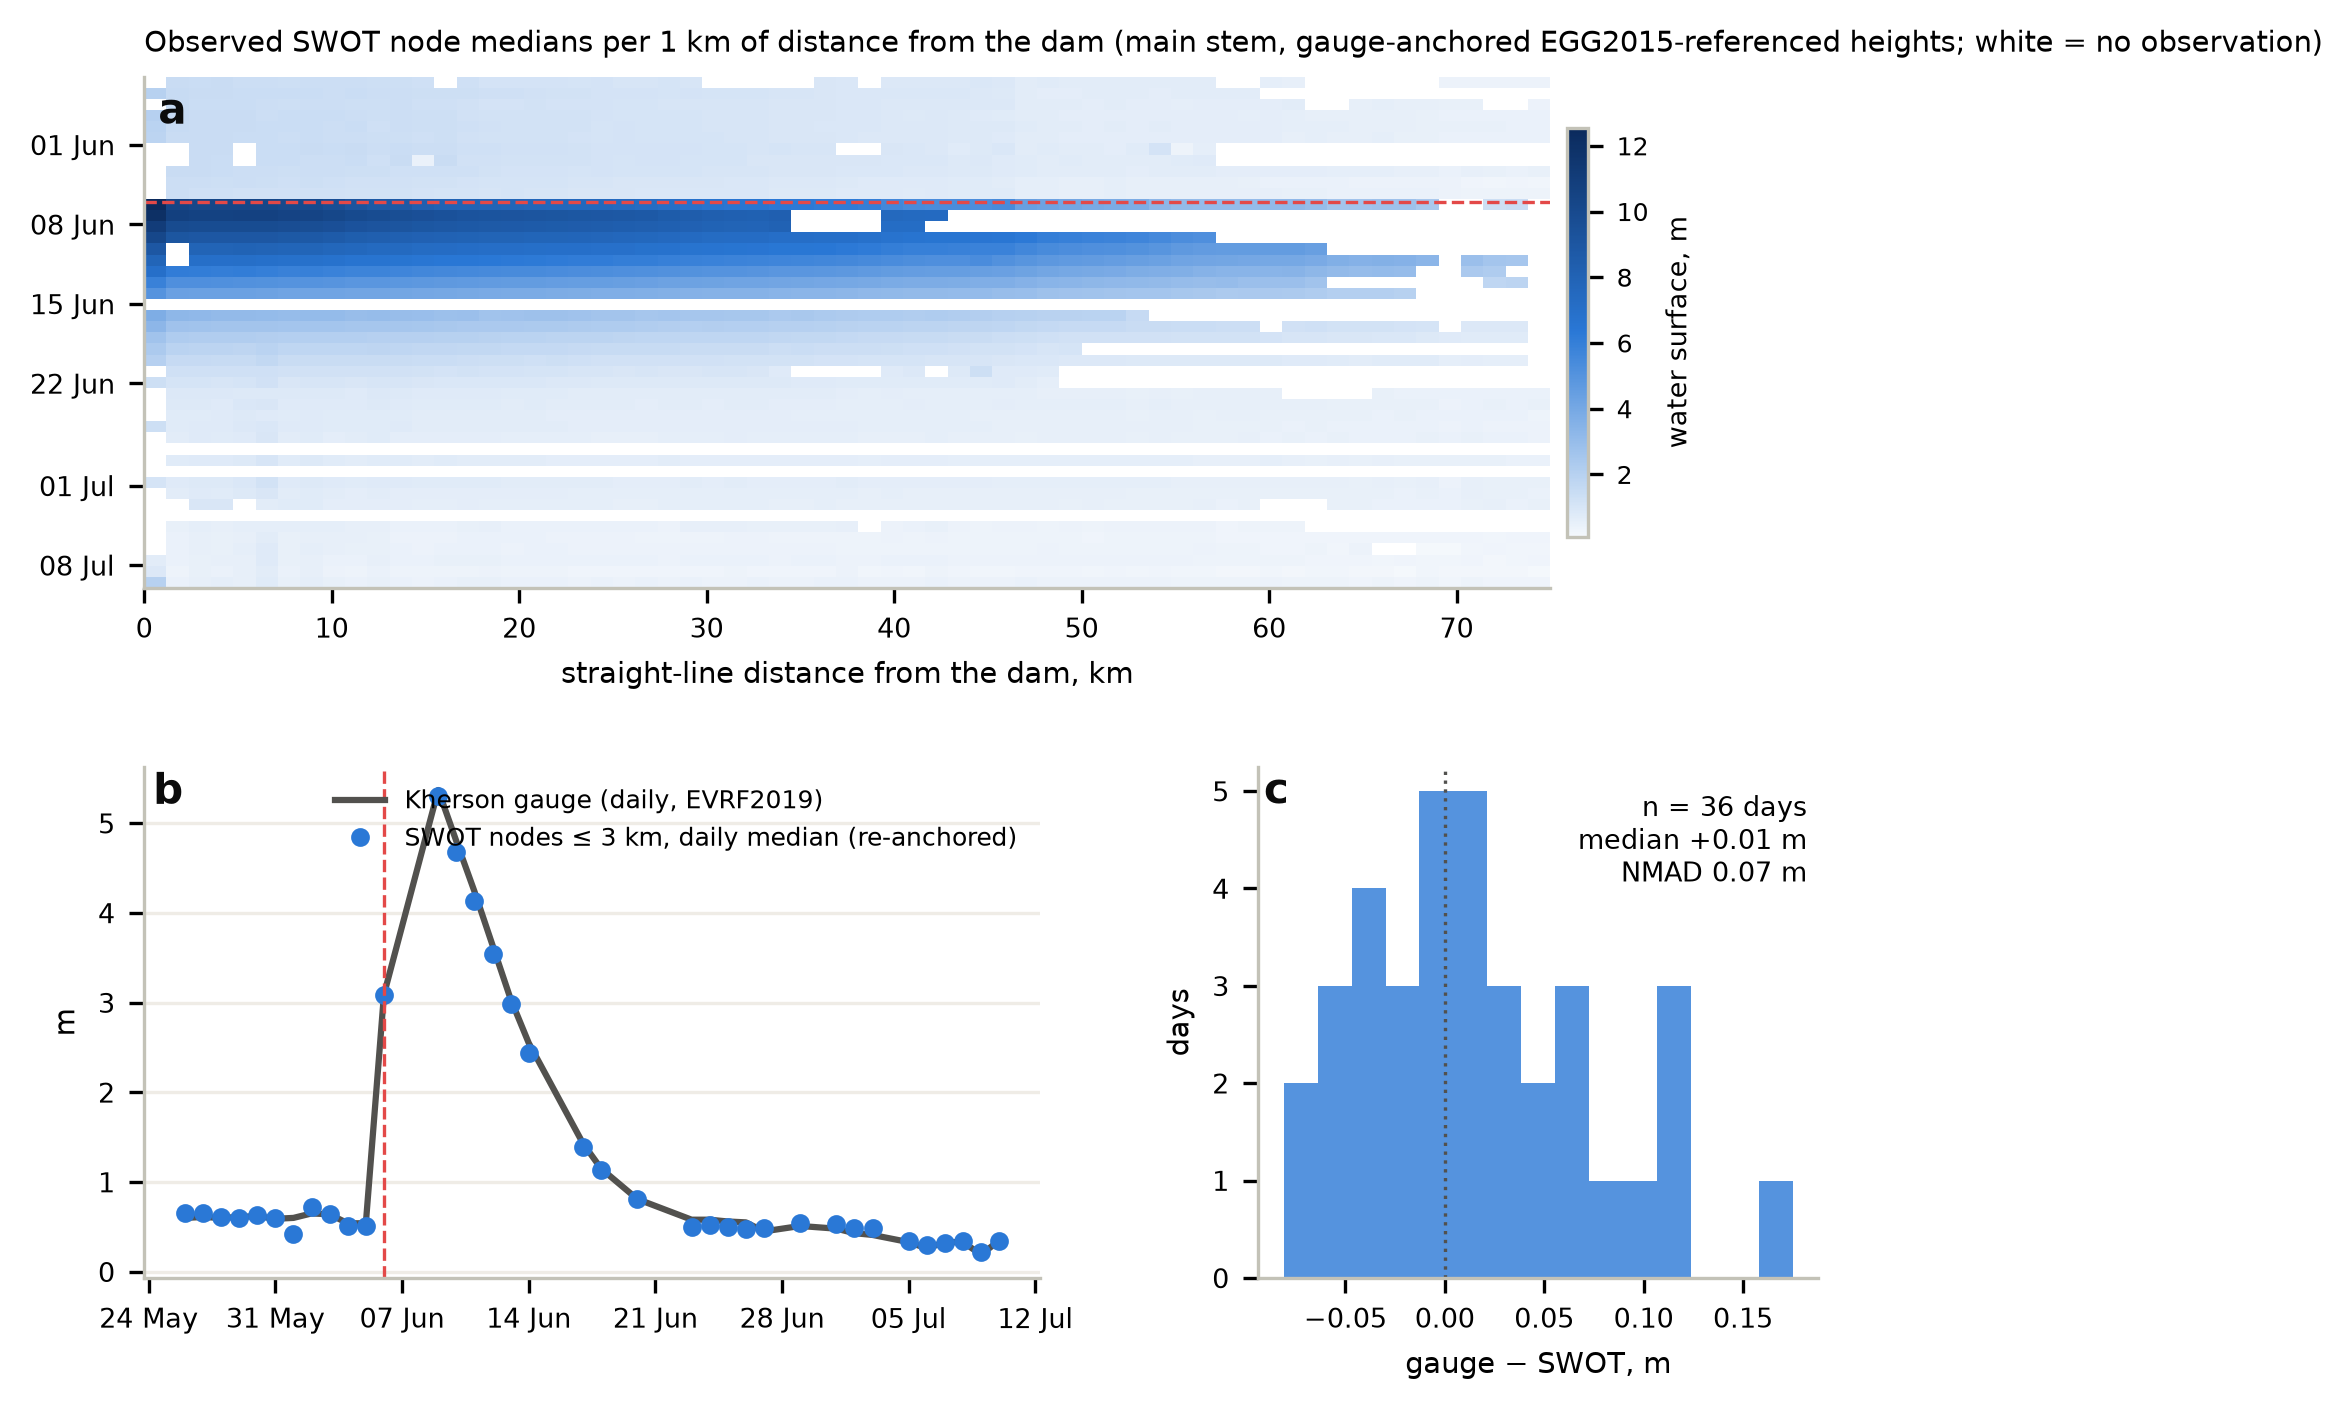

**T17** [independent_physical] SWOT-input consistency at Kherson after re-anchoring: nodes within 3 km of the gauge, daily median vs the daily gauge (river yearbook, EVRF2019). The frame validation itself is Paper 1; this only checks the p95 input.

,period,n_days,bias_m,median_m,MAE_m,RMSE_m,NMAD_m,min_m,max_m,independent_unit,sign
0,all days,36,0.016,0.006,0.048,0.062,0.066,-0.081,0.175,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...
1,pre-breach 05-26..06-05,11,0.003,-0.008,0.041,0.063,0.051,-0.070,0.175,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...
2,rise and peak 06-06..06-14,7,0.082,0.103,0.082,0.090,0.022,0.010,0.118,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...
3,recession 06-15..07-10,18,-0.002,-0.007,0.038,0.045,0.048,-0.081,0.076,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...


In [3]:
fig('Fig06'); show('T17')

## 2. Daily reconstructed series: total water-surface area, newly inundated area, volume — PRIMARY interval = the coherent Monte-Carlo worlds of p95e rev 2 (T11b-T11d)

In [4]:
d = show('T12'); d[d.region == 'DNIPRO_CORRIDOR'][['date','W_total_central_km2','W_total_p05_km2','W_total_p95_km2','A_central_km2','A_p05_km2','A_p95_km2','V_central_hm3','V_p05_hm3','V_p95_hm3','A_hand_and_ceiling_km2','A_ceiling_only_km2']]

**T12** [independent_physical] Daily terrain-reconstructed inundation per region and key date, REPORTED AS the Monte-Carlo median [p05-p95] of the coherent Monte-Carlo worlds (p95e rev 2; n_draws per row) with the deterministic nominal run (*_central_*, draw 0, a diagnostic) alongside: reconstructed TOTAL water-surface area (W_total_*: all water on the day incl. pre-breach channels, lakes and reed beds; quantiles of the total-water ensemble), reconstructed NEWLY INUNDATED area (A_*), the volume of new water (V_*) and of all water (Vtot_*), and the draw's own pre-breach baseline (baseline_*). *_emu_* = 100 000-draw emulator sensitivity envelope (p95g). The 100 000-draw emulator is not part of this table (a diagnostic, T12d). Sensitivities (nominal runs): p42 HAND rule, ceiling only, terrain as delivered (no residual bias removed), superseded closure, 4-connectivity, main-stem seed, 3-day maximum gap, river-aware water surface, the Kalynivske gauge as an extra water-surface node (the gauge then an input), nearest-node fallback capped at 10 km. Daily reconstructed series, not daily observations.

,date,W_total_central_km2,W_total_p05_km2,W_total_p95_km2,A_central_km2,A_p05_km2,A_p95_km2,V_central_hm3,V_p05_hm3,V_p95_hm3,A_hand_and_ceiling_km2,A_ceiling_only_km2
0,2023-06-05,501.3,444.9,498.2,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
3,2023-06-06,724.6,699.0,736.5,183.9,191.5,214.3,370.34,419.8,487.2,195.2,195.7
6,2023-06-07,796.6,767.3,819.4,243.2,250.3,277.8,514.47,585.0,674.0,247.9,262.3
9,2023-06-08,795.6,744.1,825.0,239.0,240.7,276.5,485.63,550.7,643.2,239.3,242.8
12,2023-06-09,740.4,703.4,779.3,187.9,201.3,236.0,446.54,516.6,610.3,222.0,200.8
15,2023-06-10,700.4,625.6,777.4,160.8,174.1,243.9,396.69,455.5,565.2,210.7,171.5
18,2023-06-11,673.1,598.5,747.9,139.5,154.6,224.2,320.30,367.6,471.0,200.6,143.3
21,2023-06-12,657.9,581.4,730.4,125.0,137.7,206.9,233.31,270.2,360.5,183.7,123.3
24,2023-06-13,640.4,561.1,712.0,107.7,119.1,186.8,157.89,186.0,267.0,159.7,105.4
27,2023-06-14,618.1,540.8,690.1,85.9,98.8,165.1,100.57,120.8,196.0,142.8,85.3


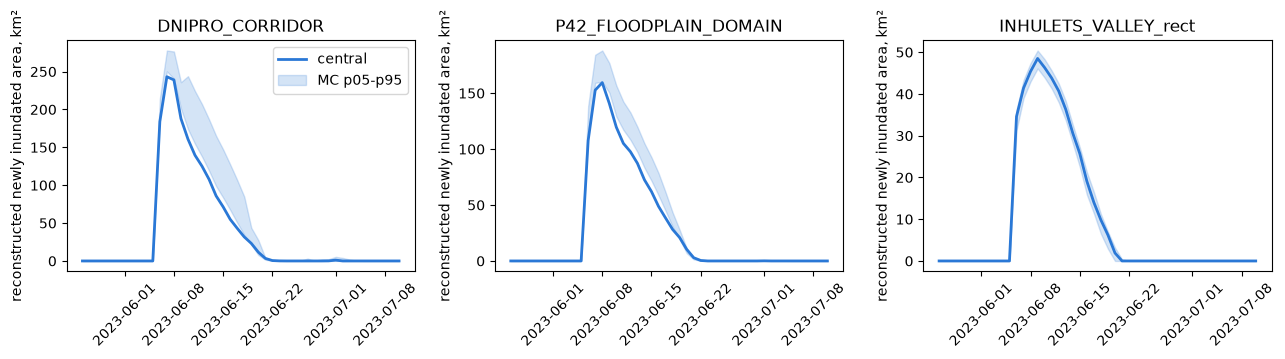

In [5]:
u = pd.read_csv(T / "p95e_area_volume_uncertainty.csv") if (T / "p95e_area_volume_uncertainty.csv").exists() else None
dd = pd.read_csv(T / "p95_daily_area_pooled_connected_ceiling.csv"); dd["t"] = pd.to_datetime(dd.date)
fig_, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, r in zip(axs, ["DNIPRO_CORRIDOR", "P42_FLOODPLAIN_DOMAIN", "INHULETS_VALLEY_rect"]):
    s = dd[dd.region == r]; ax.plot(s.t, s.new_km2, color=C["terrain"], lw=2, label="central")
    if u is not None:
        uu = u[u.region == r].copy(); uu["t"] = pd.to_datetime(uu.date); uu = uu.sort_values("t"); ax.fill_between(uu.t, uu.A_p05_km2, uu.A_p95_km2, color=C["terrain"], alpha=0.2, label="MC p05-p95")
    ax.set_title(r); ax.set_ylabel("reconstructed newly inundated area, km²"); ax.tick_params(axis="x", rotation=45)
axs[0].legend(); plt.tight_layout()

In [6]:
show('T11b')

**T11b** [independent_physical] Uncertainty components of the terrain reconstruction (Monte-Carlo inputs, p95e rev 2): datum closure of the SWOT chain, gauge, SWOT node height, gap-dependent interpolation error, the correlation model of the terrain-error field (nugget + nested exponential structures fitted to the standardized FABDEM - ICESat-2 residuals, p95j) and the class-wise FABDEM residual scale per zone (own zone where N >= 500, else pooled and flagged transferred); bed cells of the seamless terrain-bed model carry no stochastic term (limitation).

,component,sigma_m,applied,source,sigma_by_gap_m,range_m,nugget_share,structures,model,zone,bias_m,rmse_m,n,transferred
0,datum_closure_kherson,0.050,"one scalar per draw, every SWOT node and day (...",Paper 1 Table 5 / Sec. 5.12 (NMAD 4-5 cm at Kh...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gauge_daily,0.050,one scalar per draw on the gauge node (local n...,date-only daily values; two yearbooks differ b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,swot_node_wse_u,0.092,"observed node-days, independent per node-day","p59 nodes, median wse_u",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,interpolation_gap_cv,0.066,interpolated / held node-days: one standard no...,p95e gap_cv (gap-matched),1-1 d: interp 0.066 / held 0.089; 2-2 d: inter...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pass_level_swot,0.000,per-day scalar shared by all SWOT nodes; 0 in ...,Paper 1 daily closure scatter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,terrain_field_correlation,NaN,"unit-variance FFT field on the union mosaic, o...",POOLED standardized residual (r - b_c) / sigma...,NaN,1172.0,0.08,0.50 x exp(-h/123 m); 0.42 x exp(-h/1172 m),nested_2exp+nugget,NaN,NaN,NaN,NaN,NaN
6,terrain_trees,1.711,class NMAD as the marginal sigma of the correl...,ZONE_4_DAM_TO_KHERSON_FLOODWAY (FABDEM - ICESa...,NaN,NaN,NaN,NaN,NaN,ZONE_4_DAM_TO_KHERSON_FLOODWAY,1.698,2.880,30023.0,False
7,terrain_grass,0.621,class NMAD as the marginal sigma of the correl...,ZONE_4_DAM_TO_KHERSON_FLOODWAY (FABDEM - ICESa...,NaN,NaN,NaN,NaN,NaN,ZONE_4_DAM_TO_KHERSON_FLOODWAY,0.385,1.500,98993.0,False
8,terrain_cropland,0.295,class NMAD as the marginal sigma of the correl...,ZONE_4_DAM_TO_KHERSON_FLOODWAY (FABDEM - ICESa...,NaN,NaN,NaN,NaN,NaN,ZONE_4_DAM_TO_KHERSON_FLOODWAY,0.151,0.351,307849.0,False
9,terrain_built,0.597,class NMAD as the marginal sigma of the correl...,ZONE_4_DAM_TO_KHERSON_FLOODWAY (FABDEM - ICESa...,NaN,NaN,NaN,NaN,NaN,ZONE_4_DAM_TO_KHERSON_FLOODWAY,0.172,1.116,15309.0,False


### Observational support of the new area (D-SUPPORT): the full terrain-connectivity reconstruction is the primary product; its direct (<= 3 km), extrapolated (3-10 km) and weak (> 10 km) parts, the supported core and the 10 km cap sensitivity

In [7]:
show('T11k')

**T11k** [independent_physical] Observational support of the reconstructed new inundation (nominal run of the primary rule; maintainer decision D-SUPPORT): per region and key date the FULL terrain-connectivity reconstruction (the primary product), its DIRECT (nearest SWOT node <= 3 km), EXTRAPOLATED (3-10 km) and WEAK (> 10 km) parts, the SUPPORTED CORE (<= 10 km), the weak share, the parts capped at the Kherson gauge and, in the Inhulets valley, served by a node of another river (cross-river flag), and the 10 km cap run of p95 as a sensitivity (it recomputes the connectivity; it is not the core). The 3 and 10 km limits are operational thresholds, not physical constants.

,date,region,A_full_km2,A_direct_km2,A_extrapolated_km2,A_weak_km2,A_core_le10km_km2,share_weak,A_gauge_capped_km2,A_cross_river_km2,A_cap10km_sensitivity_km2,note
0,2023-06-06,DNIPRO_CORRIDOR,183.82,54.45,73.25,56.11,127.71,0.3053,0.0,NaN,126.1,nominal run of the primary rule; classes by th...
1,2023-06-06,INHULETS_VALLEY_rect,34.55,0.29,1.85,32.41,2.14,0.9382,0.0,11.02,2.1,nominal run of the primary rule; classes by th...
2,2023-06-06,P42_FLOODPLAIN_DOMAIN,107.73,48.75,55.68,3.30,104.42,0.0307,0.0,NaN,104.4,nominal run of the primary rule; classes by th...
3,2023-06-07,DNIPRO_CORRIDOR,243.20,73.09,108.45,61.66,181.54,0.2535,0.0,NaN,180.2,nominal run of the primary rule; classes by th...
4,2023-06-07,INHULETS_VALLEY_rect,41.43,0.41,2.56,38.46,2.97,0.9283,0.0,11.27,3.0,nominal run of the primary rule; classes by th...
5,2023-06-07,P42_FLOODPLAIN_DOMAIN,152.72,60.76,82.12,9.85,142.88,0.0645,0.0,NaN,142.9,nominal run of the primary rule; classes by th...
6,2023-06-08,DNIPRO_CORRIDOR,238.98,74.96,115.52,48.50,190.48,0.2029,0.0,NaN,190.5,nominal run of the primary rule; classes by th...
7,2023-06-08,INHULETS_VALLEY_rect,45.39,0.53,3.08,41.78,3.61,0.9204,0.0,10.84,3.6,nominal run of the primary rule; classes by th...
8,2023-06-08,P42_FLOODPLAIN_DOMAIN,159.45,61.17,89.32,8.96,150.49,0.0562,0.0,NaN,150.5,nominal run of the primary rule; classes by th...
9,2023-06-09,DNIPRO_CORRIDOR,187.88,70.00,104.72,13.16,174.71,0.0701,0.0,NaN,174.7,nominal run of the primary rule; classes by th...


### Computational diagnostic, not evidence (D-EMU): the 100 000-draw emulator (p95g) has no connectivity and a total built around the nominal run; no reported number rests on it

In [8]:
show('T12d')

**T12d** [contextual] Computational diagnostic, not evidence (maintainer decision D-EMU, 2026-09-29): the 100 000-draw cluster-normal emulator (p95g) per region and key date. It has no connectivity, its total water-surface envelope is built around the nominal total, and its volumes are unanchored; it is not an uncertainty estimate and no reported number rests on it. The primary interval is the Monte-Carlo ensemble (T12).

,region,date,n_draws,area_semantics,A_new_km2_mean,A_new_km2_p05,A_new_km2_p25,A_new_km2_p50,A_new_km2_p75,A_new_km2_p95,V_new_hm3_mean,V_new_hm3_p05,V_new_hm3_p25,V_new_hm3_p50,V_new_hm3_p75,V_new_hm3_p95,W_total_central_km2,A_new_central_km2,W_total_km2_mean,W_total_km2_p05,W_total_km2_p25,W_total_km2_p50,W_total_km2_p75,W_total_km2_p95,W_total_emulator_raw_p50_km2,status
0,DNIPRO_CORRIDOR,2023-06-05,100000,terrain_reconstructed,2.14,0.00,0.00,0.00,0.00,16.32,205.88,165.90,188.08,204.95,222.63,249.22,501.3,0.0,503.44,501.30,501.30,501.30,501.30,517.62,750.5,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
1,DNIPRO_CORRIDOR,2023-06-06,100000,terrain_reconstructed,204.56,168.41,189.05,204.08,219.43,242.45,1466.08,1381.72,1431.00,1465.44,1500.48,1552.44,724.6,183.9,745.26,709.11,729.75,744.78,760.13,783.15,984.2,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
2,DNIPRO_CORRIDOR,2023-06-07,100000,terrain_reconstructed,262.27,226.03,246.69,261.64,277.37,300.53,1771.96,1678.17,1732.87,1771.36,1810.33,1867.25,796.6,243.2,815.67,779.43,800.09,815.04,830.77,853.93,1042.0,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
3,DNIPRO_CORRIDOR,2023-06-08,100000,terrain_reconstructed,252.37,215.89,236.70,251.90,267.42,290.69,1783.73,1690.52,1745.04,1783.29,1821.86,1878.59,795.6,239.0,808.97,772.49,793.30,808.50,824.02,847.29,1032.1,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
4,DNIPRO_CORRIDOR,2023-06-09,100000,terrain_reconstructed,219.36,182.55,203.50,218.80,234.64,258.01,1785.81,1697.28,1748.73,1785.32,1822.31,1876.65,740.4,187.9,771.86,735.05,756.00,771.30,787.14,810.51,998.8,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
5,DNIPRO_CORRIDOR,2023-06-10,100000,terrain_reconstructed,191.34,156.71,176.45,190.79,205.59,227.75,1664.64,1580.74,1629.70,1664.37,1699.09,1749.66,700.4,160.8,730.94,696.31,716.05,730.39,745.19,767.35,971.0,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
6,DNIPRO_CORRIDOR,2023-06-11,100000,terrain_reconstructed,168.12,133.90,153.33,167.48,182.31,204.40,1467.01,1388.30,1434.03,1466.58,1499.37,1547.28,673.1,139.5,701.72,667.50,686.93,701.08,715.91,738.00,947.7,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
7,DNIPRO_CORRIDOR,2023-06-12,100000,terrain_reconstructed,145.66,111.64,130.88,145.08,159.66,181.99,1215.82,1142.39,1185.09,1215.43,1246.02,1290.53,657.9,125.0,678.56,644.54,663.78,677.98,692.56,714.89,925.3,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
8,DNIPRO_CORRIDOR,2023-06-13,100000,terrain_reconstructed,124.76,90.53,109.97,124.16,138.89,161.03,988.44,919.69,959.45,987.86,1016.85,1059.18,640.4,107.7,657.46,623.23,642.67,656.86,671.59,693.73,904.4,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."
9,DNIPRO_CORRIDOR,2023-06-14,100000,terrain_reconstructed,104.64,70.24,89.72,104.05,118.93,141.27,795.93,731.91,768.88,795.40,822.40,862.39,618.1,85.9,636.84,602.44,621.92,636.25,651.13,673.47,884.3,"DIAGNOSTIC, not evidence (D-EMU): cluster-norm..."


### Reservoir side of the balance (T21, T22, Fig09, FigS07): daily-MEAN effective release (-dV/dt + Q_in), not an instantaneous breach discharge; hypsometry DEM vs design is the open question of Paper 4 (historical bathymetry)

**T21** [independent_physical] Kakhovka pool during the drawdown, per day: levels at the outlet (SWOT), Nikopol (press) and Rozumivka (gauge), surface gradient, pool water area and volume under the sloped surface (seamless DEM inside the pre-breach pool polygon), daily volume change, DniproHES inflow, the daily-mean effective release (-dV/dt + Q_in; not an instantaneous breach discharge), and the downstream new-water volume and total water surface (terrain reconstruction) with the Kherson stage.

**T22** [independent_physical] Pool hypsometry from the seamless DEM (level surface) against the design Table 19 (BS-77 levels + 0.185 m), with the relative difference dV/V_design and dA/A_design per level: the seamless DEM gives less volume at the same level: -8.5 % at the full-pool level (17.5 m), -14 % at 13 m, -20 % at 11 m (open question for Paper 4: reservoir bowl on the historical bathymetry).

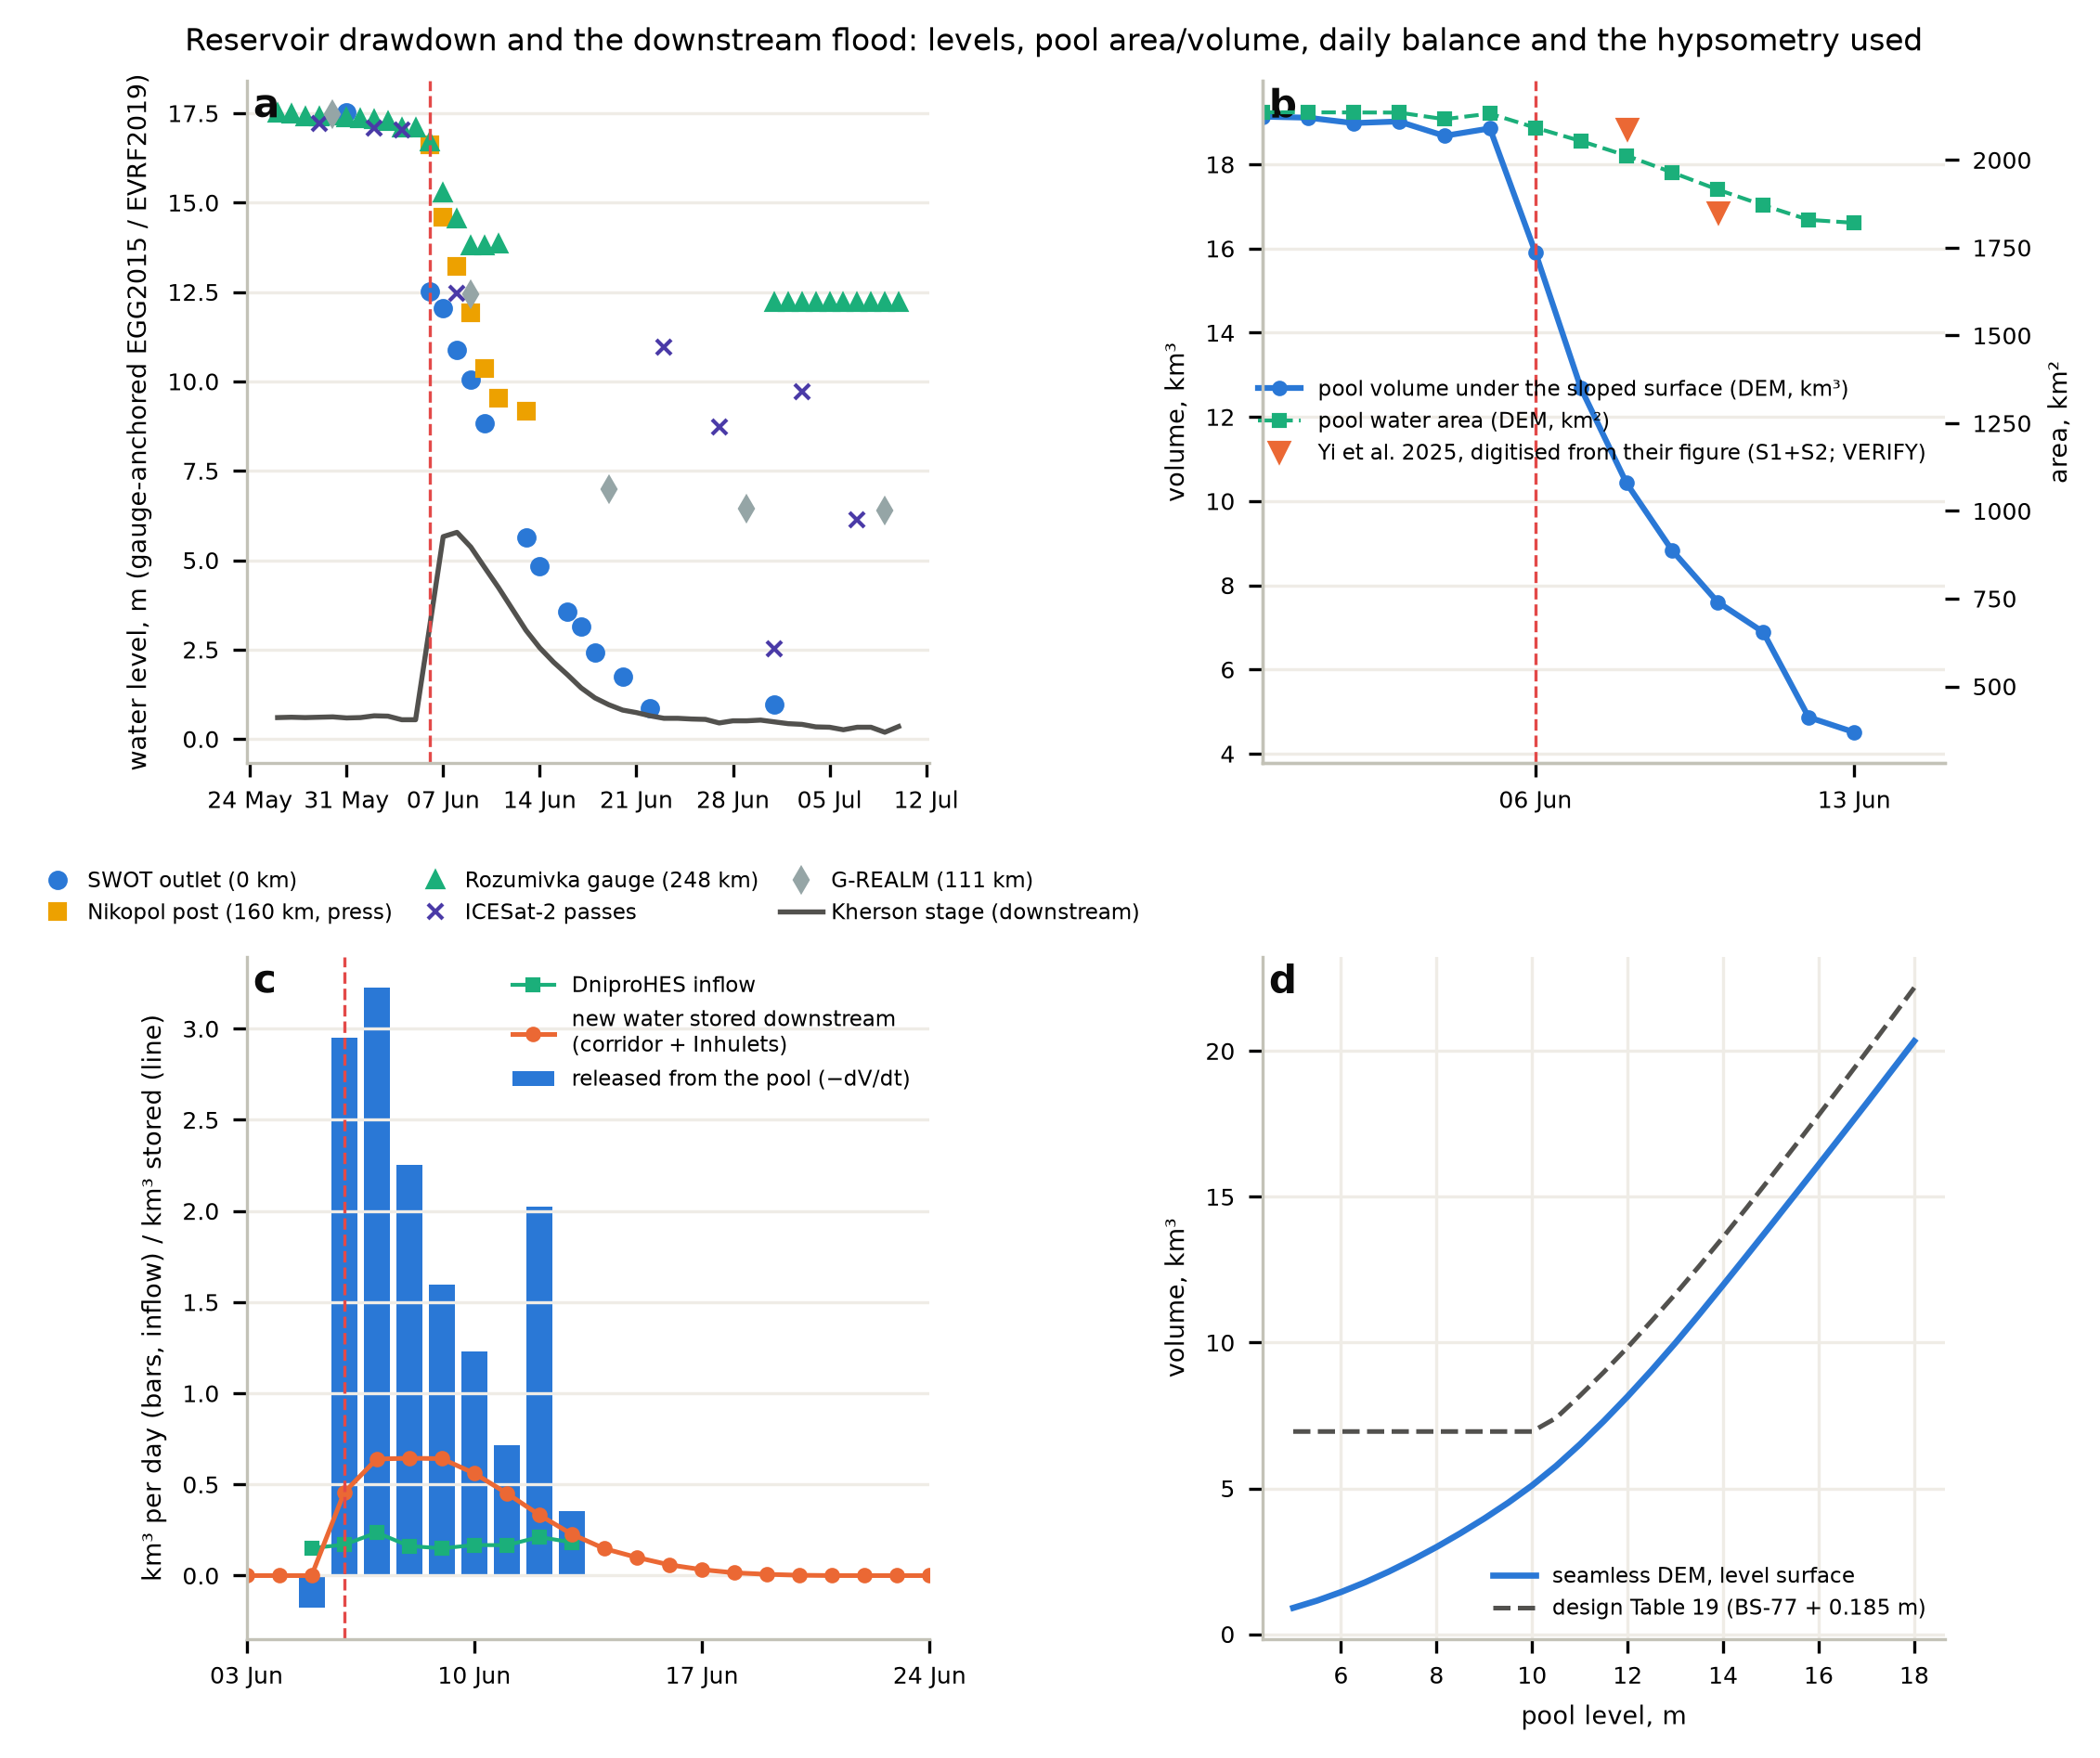

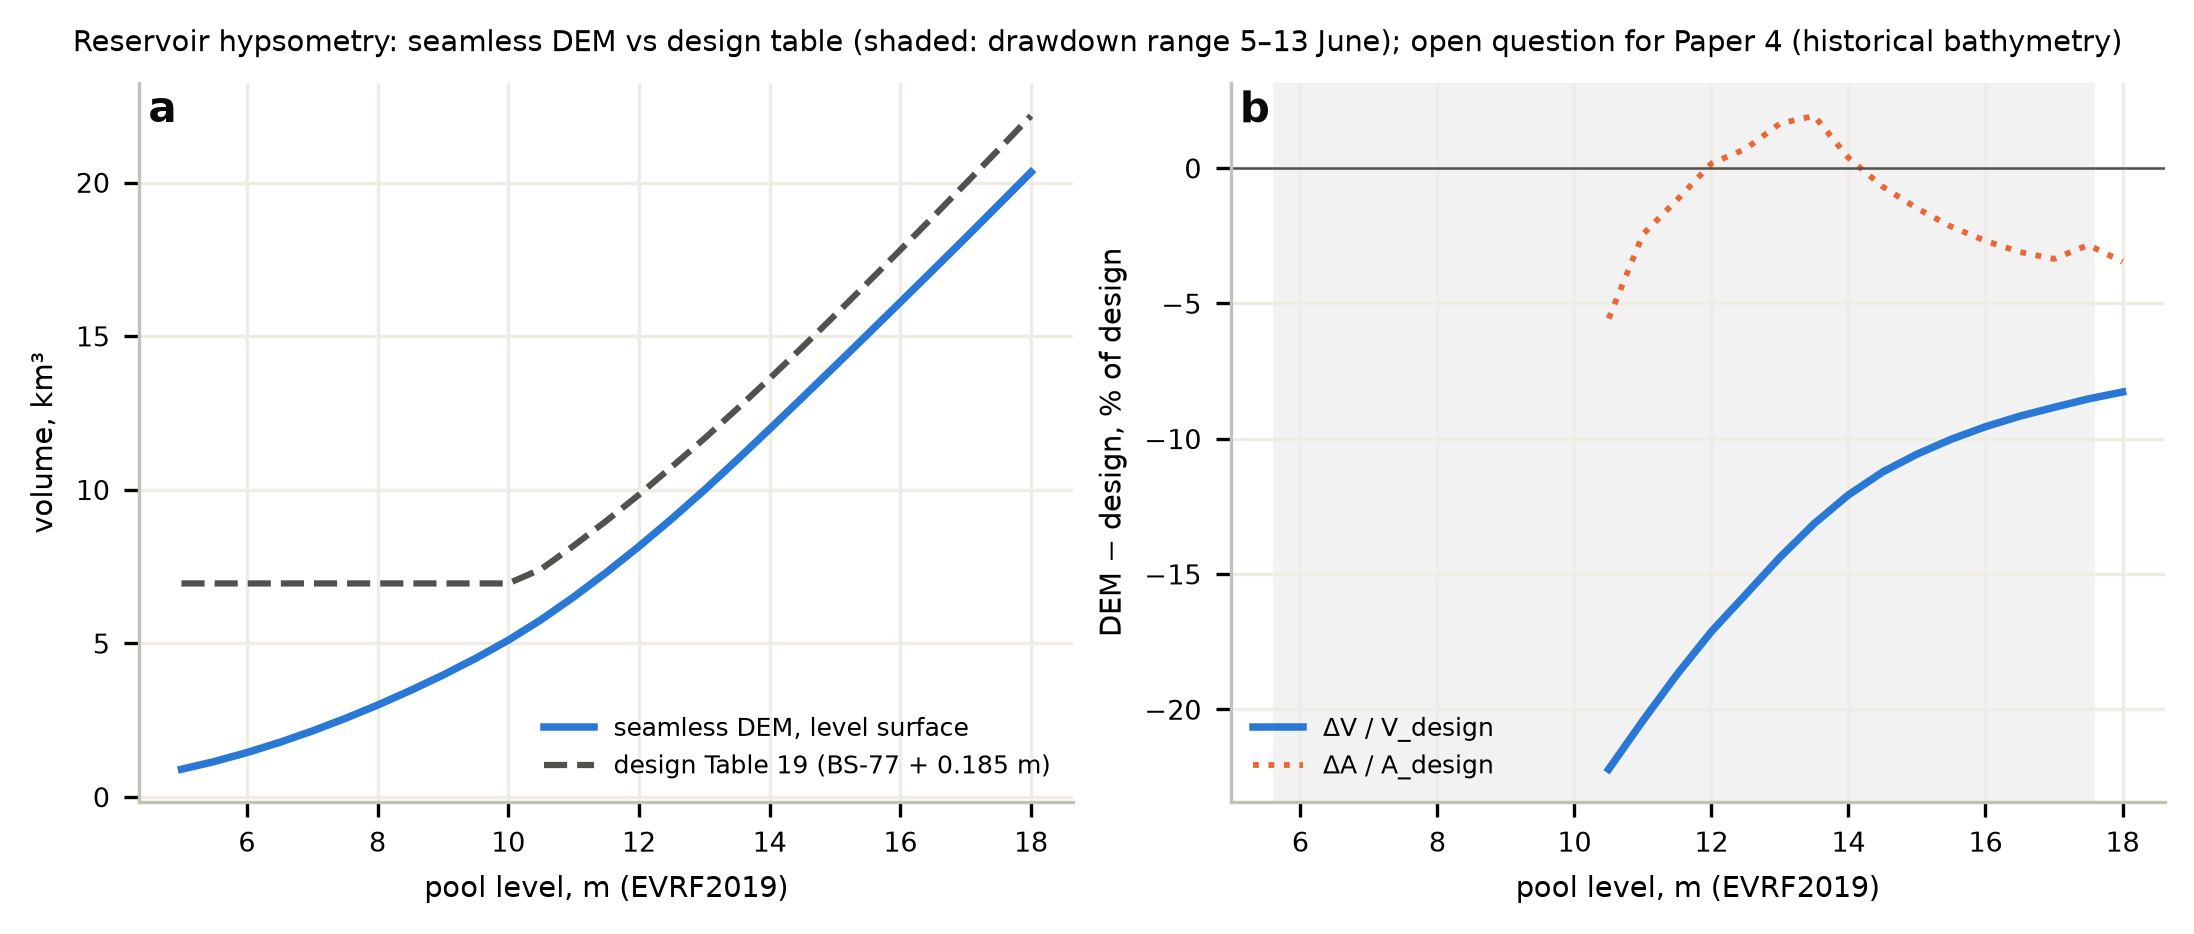

In [9]:
show('T21'); show('T22'); fig('Fig09'); fig('FigS07')

## 3. Cross-sensor check against Sentinel-1 (per acquisition date)
Raw POD / FAR / CSI on the S1 observation domain are primary; the conditional POD outside the normally-wet class is a diagnostic conditional agreement (a-priori class), never a corrected POD.

In [10]:
v = show('T13'); v[(v.variant == 'connected_ceiling') & v.date.isin(['2023-06-09','2023-06-13','2023-06-14','2023-06-18','2023-06-21'])][['date','region','s1_new_km2','hand_new_km2','hit_km2','miss_km2','miss_on_normally_wet_km2','hand_only_km2','POD','FAR','CSI','POD_cond_outside_normally_wet']]

**T13** [cross_sensor] Terrain reconstruction vs Sentinel-1 new dark water per acquisition date, region and variant: hit / miss / miss-on-normally-wet / terrain-only km2, POD, FAR, CSI (raw agreement, primary) and the conditional POD outside the normally-wet class (diagnostic).

,date,region,s1_new_km2,hand_new_km2,hit_km2,miss_km2,miss_on_normally_wet_km2,hand_only_km2,POD,FAR,CSI,POD_cond_outside_normally_wet
9,2023-06-09,DNIPRO_CORRIDOR,319.4,182.3,56.5,262.9,177.3,125.9,0.177,0.690,0.127,0.398
10,2023-06-09,INHULETS_VALLEY_rect,36.2,18.3,12.1,24.1,16.0,6.2,0.334,0.339,0.285,0.599
11,2023-06-09,P42_FLOODPLAIN_DOMAIN,201.2,136.4,49.4,151.8,150.4,87.0,0.246,0.638,0.171,0.972
12,2023-06-13,DNIPRO_CORRIDOR,164.9,107.3,22.4,142.5,132.3,84.9,0.136,0.791,0.090,0.687
13,2023-06-13,INHULETS_VALLEY_rect,27.0,13.8,10.0,17.0,16.5,3.8,0.370,0.275,0.325,0.952
14,2023-06-13,P42_FLOODPLAIN_DOMAIN,147.3,87.0,21.6,125.7,124.1,65.4,0.147,0.752,0.102,0.931
15,2023-06-14,DNIPRO_CORRIDOR,99.3,85.6,11.2,88.1,65.7,74.3,0.113,0.869,0.065,0.333
16,2023-06-14,INHULETS_VALLEY_rect,25.4,12.8,8.5,16.9,16.0,4.3,0.335,0.336,0.286,0.904
17,2023-06-14,P42_FLOODPLAIN_DOMAIN,74.0,72.2,11.0,63.0,60.5,61.2,0.149,0.848,0.081,0.815
18,2023-06-18,DNIPRO_CORRIDOR,53.6,26.0,0.5,53.2,5.3,25.6,0.009,0.981,0.006,0.010


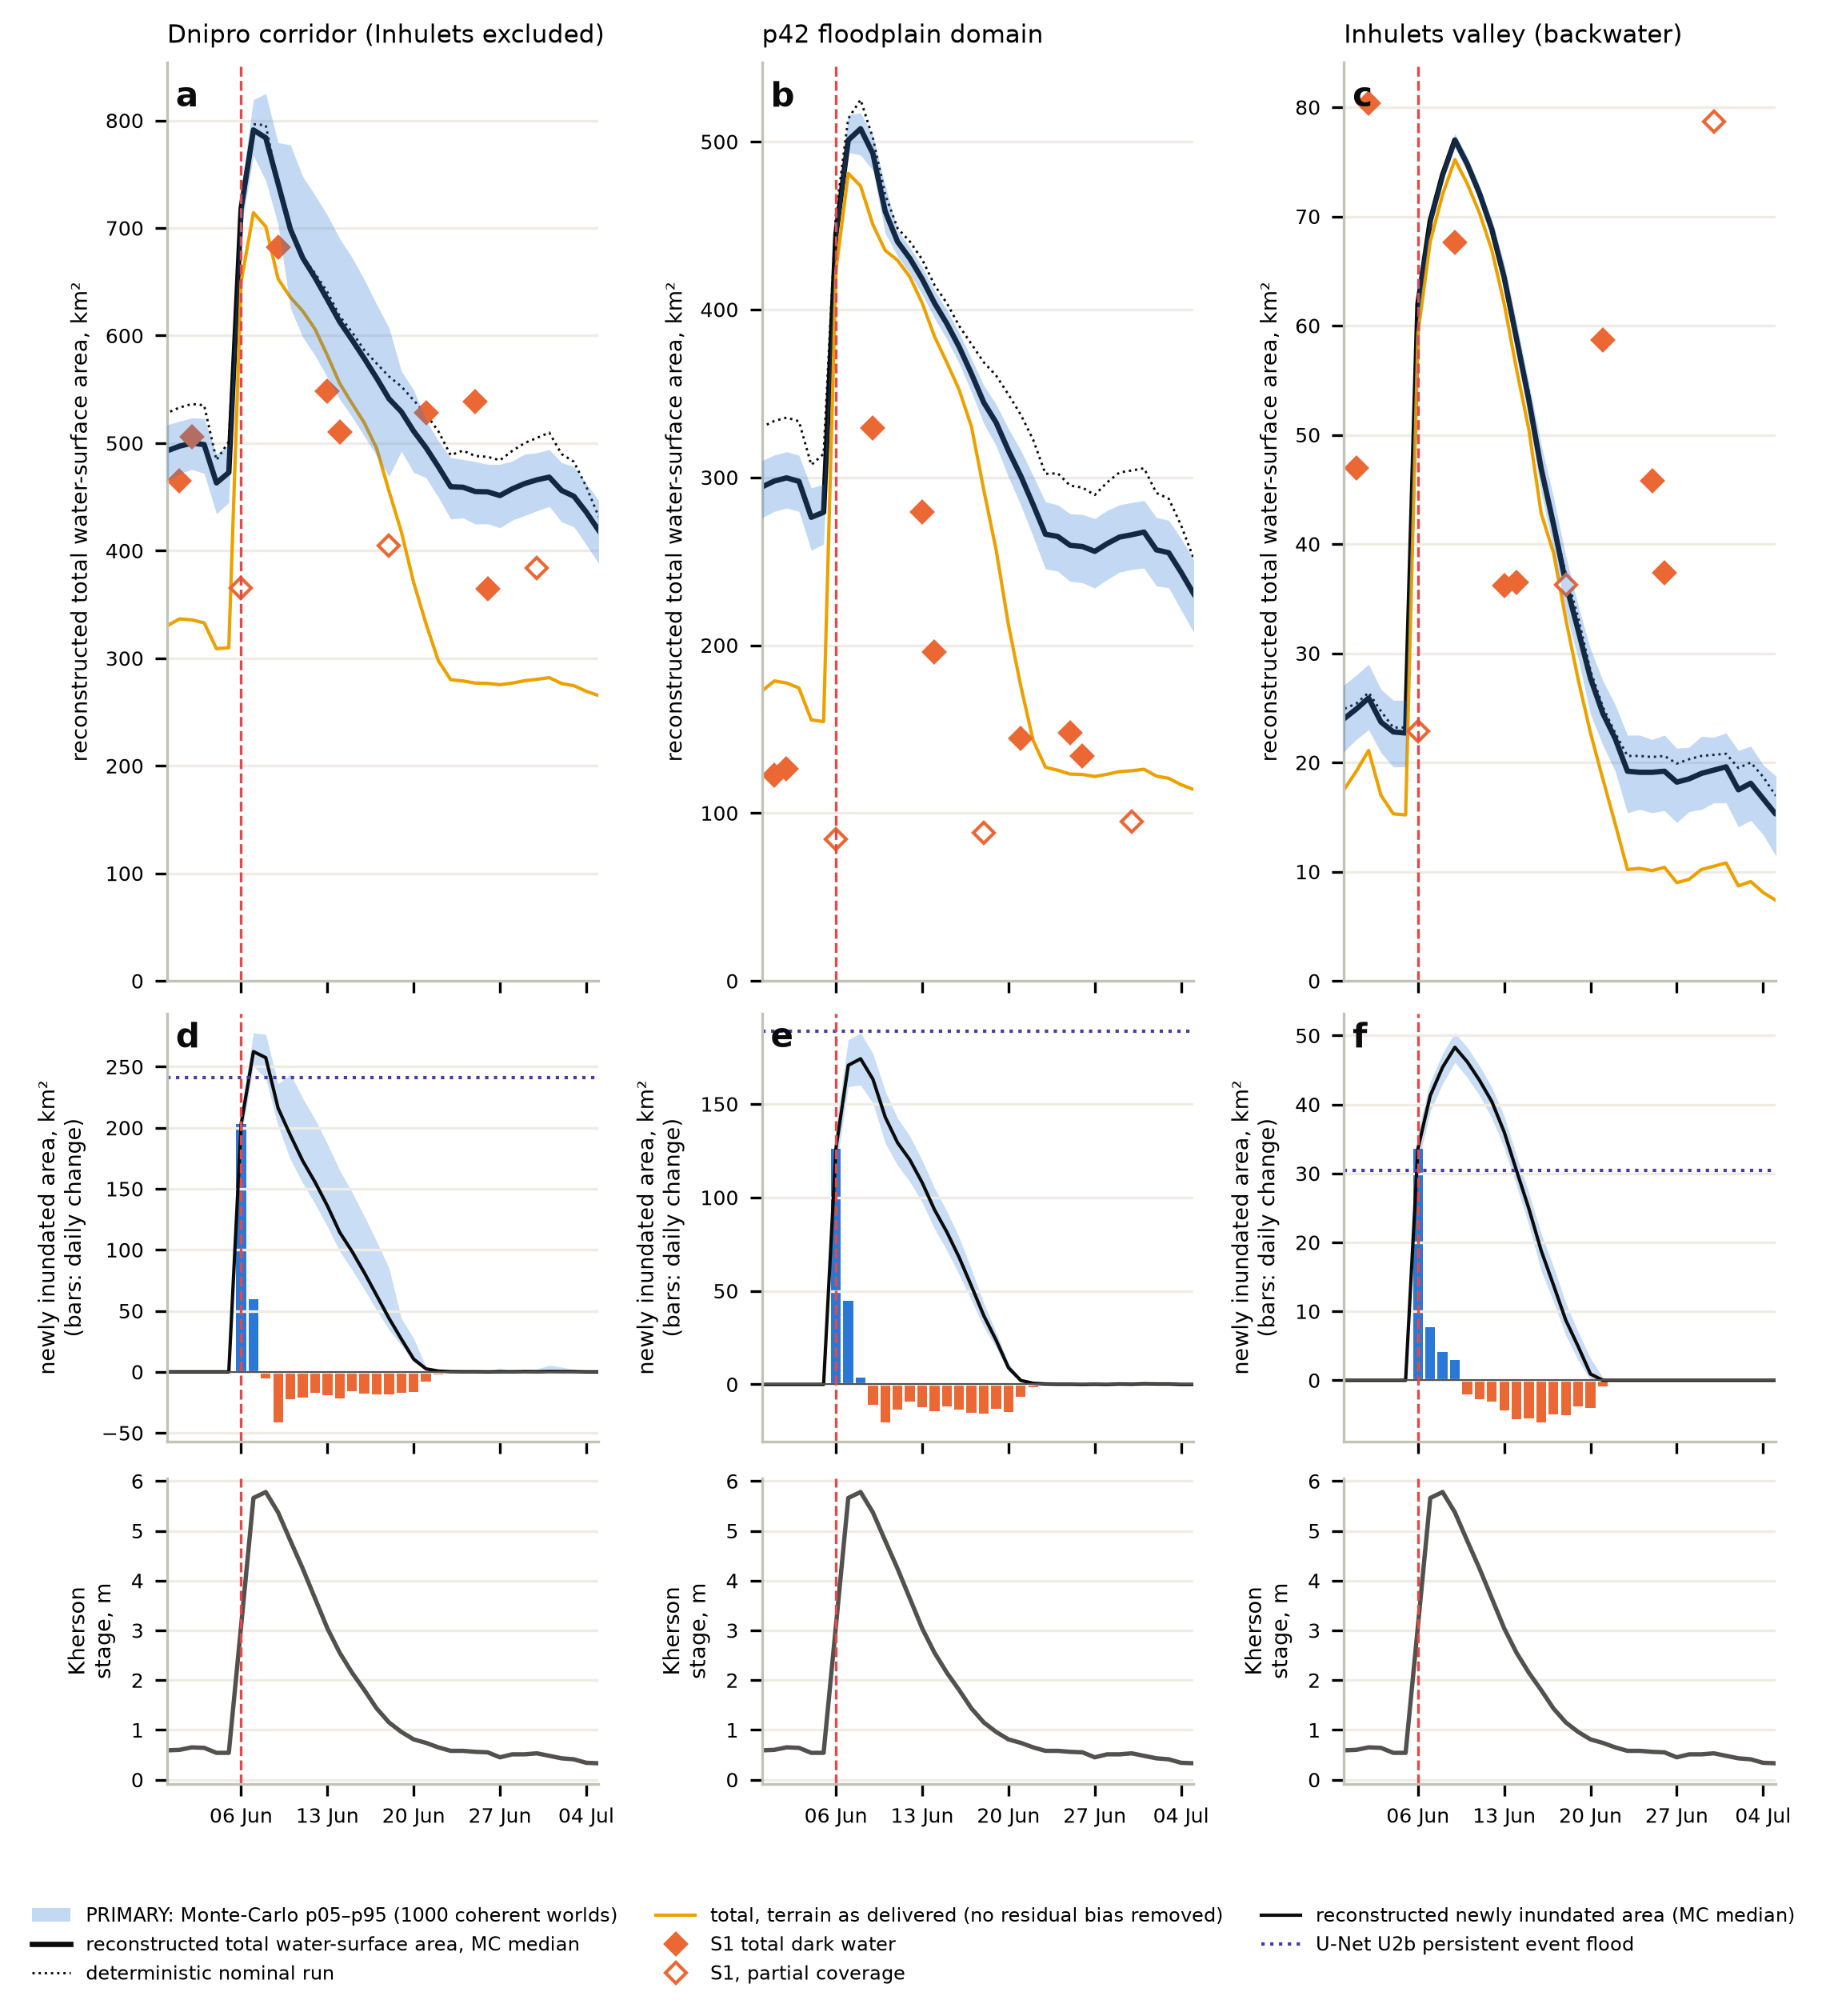

In [11]:
fig('Fig04')

## 4. Disagreement ontology (A both / B terrain-only / C S1-only)
B decomposed by land cover (SAR blind spots); C by ground elevation relative to the surface (submergence of normally-wet reeds vs S1-only detections topographically unsupported by the reconstructed water surface).

In [12]:
o = show('T14'); o[o.date == '2023-06-09']

**T14** [contextual] Disagreement ontology terrain x Sentinel-1 by zone and date: category areas split by ground elevation relative to the water surface, normally-wet flag, WorldCover and RF20 classes (km2).

,zone,date,category,km2,km2_ground_below_surface,km2_ground_0_2m_above,km2_ground_2_5m_above,km2_ground_ge5m_above,km2_normally_wet,km2_wc_trees,km2_wc_wetland,km2_wc_built,km2_wc_cropland,km2_wc_grass,km2_wc_bare,km2_p73_reed,km2_p73_forest,km2_p73_built,km2_p73_cropland,category_meaning
0,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,A,24.07,24.07,0.00,0.00,0.00,0.00,0.81,4.62,0.66,1.33,16.26,0.07,3.86,1.24,1.47,1.25,terrain+ / S1+
1,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,B,72.66,72.66,0.00,0.00,0.00,0.00,29.04,5.10,10.62,1.56,25.70,0.08,4.25,26.58,13.01,1.71,terrain+ / S1- (sensor blind spot or reconstru...
2,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,C,110.82,77.02,1.54,3.60,28.67,76.68,2.90,70.62,0.12,25.27,9.65,0.21,71.51,2.95,0.34,5.74,terrain- / S1+ (submergence signal on normally...
3,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,N,1864.58,309.40,97.60,208.66,1248.57,60.40,249.45,19.53,80.11,866.52,400.66,7.22,31.04,209.36,80.47,441.61,neither
4,ZONE_2_KHERSON_DELTA,2023-06-09,A,32.41,32.41,0.00,0.00,0.00,0.00,0.47,23.58,1.01,0.37,6.55,0.07,21.05,0.64,2.25,0.46,terrain+ / S1+
5,ZONE_2_KHERSON_DELTA,2023-06-09,B,53.20,53.20,0.00,0.00,0.00,0.00,15.53,14.24,13.78,0.18,8.98,0.10,12.03,13.94,16.46,0.18,terrain+ / S1- (sensor blind spot or reconstru...
6,ZONE_2_KHERSON_DELTA,2023-06-09,C,152.12,92.91,31.23,3.03,24.95,100.58,1.79,119.75,0.26,12.55,16.32,0.09,119.01,1.00,1.04,10.81,terrain- / S1+ (submergence signal on normally...
7,ZONE_2_KHERSON_DELTA,2023-06-09,N,883.28,170.36,50.06,36.24,619.86,37.29,117.24,59.70,75.83,289.25,205.21,1.99,67.39,102.43,85.93,246.57,neither


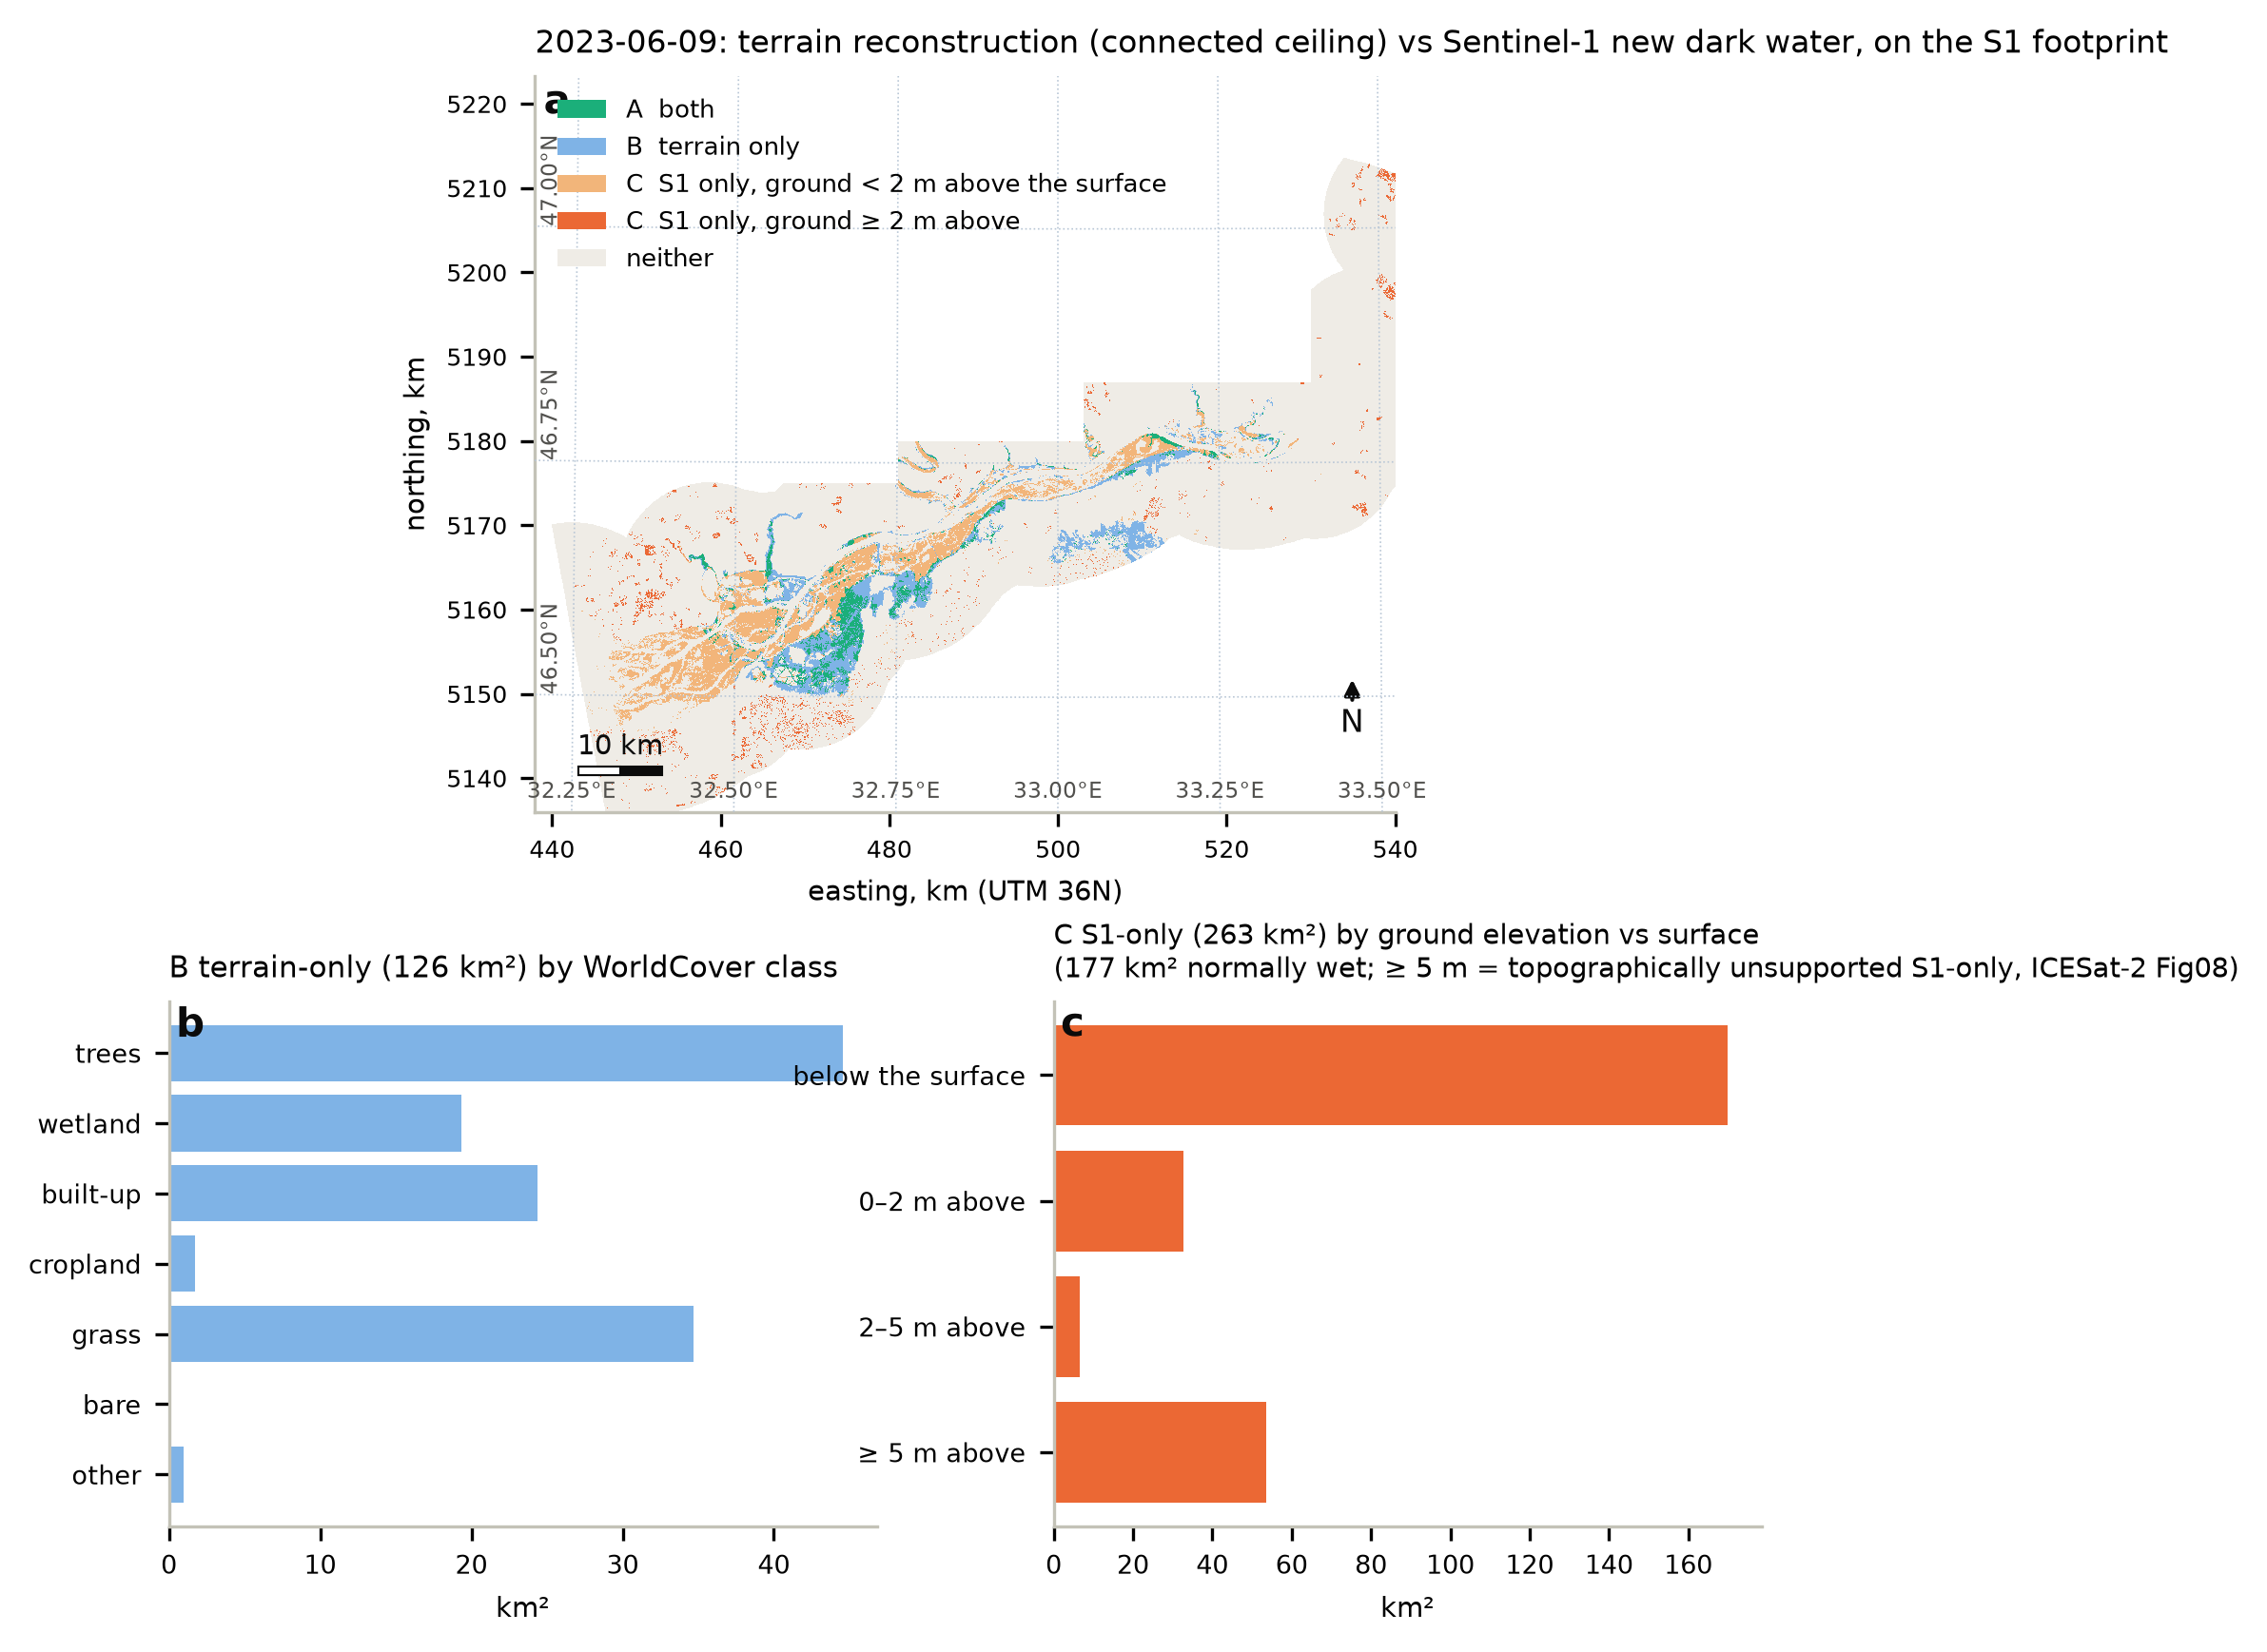

In [13]:
fig('Fig05')

## 5. ICESat-2 altimetric consistency check
A track-based consistency check of the DEM and the water surface, not a validation of the inundation map.

**T15** [independent_physical] ICESat-2 altimetric consistency check per zone and agreement category on 9 June (categories inside the S1 valid footprint only, review F12): residual of the FABDEM-sourced terrain minus night ICESat-2 ground, raw (res_*) and after the class-bias correction used by the reconstruction (res_corr_*; median, p10, p90), ICESat-2 ground minus water surface, share of segments below the surface; N segments, n_dates acquisition dates, n_bed_source segments on bed-sourced cells (excluded from the residual statistics). The same p57 night corpus also calibrates the class bias, so this is a consistency check, not an independent validation.

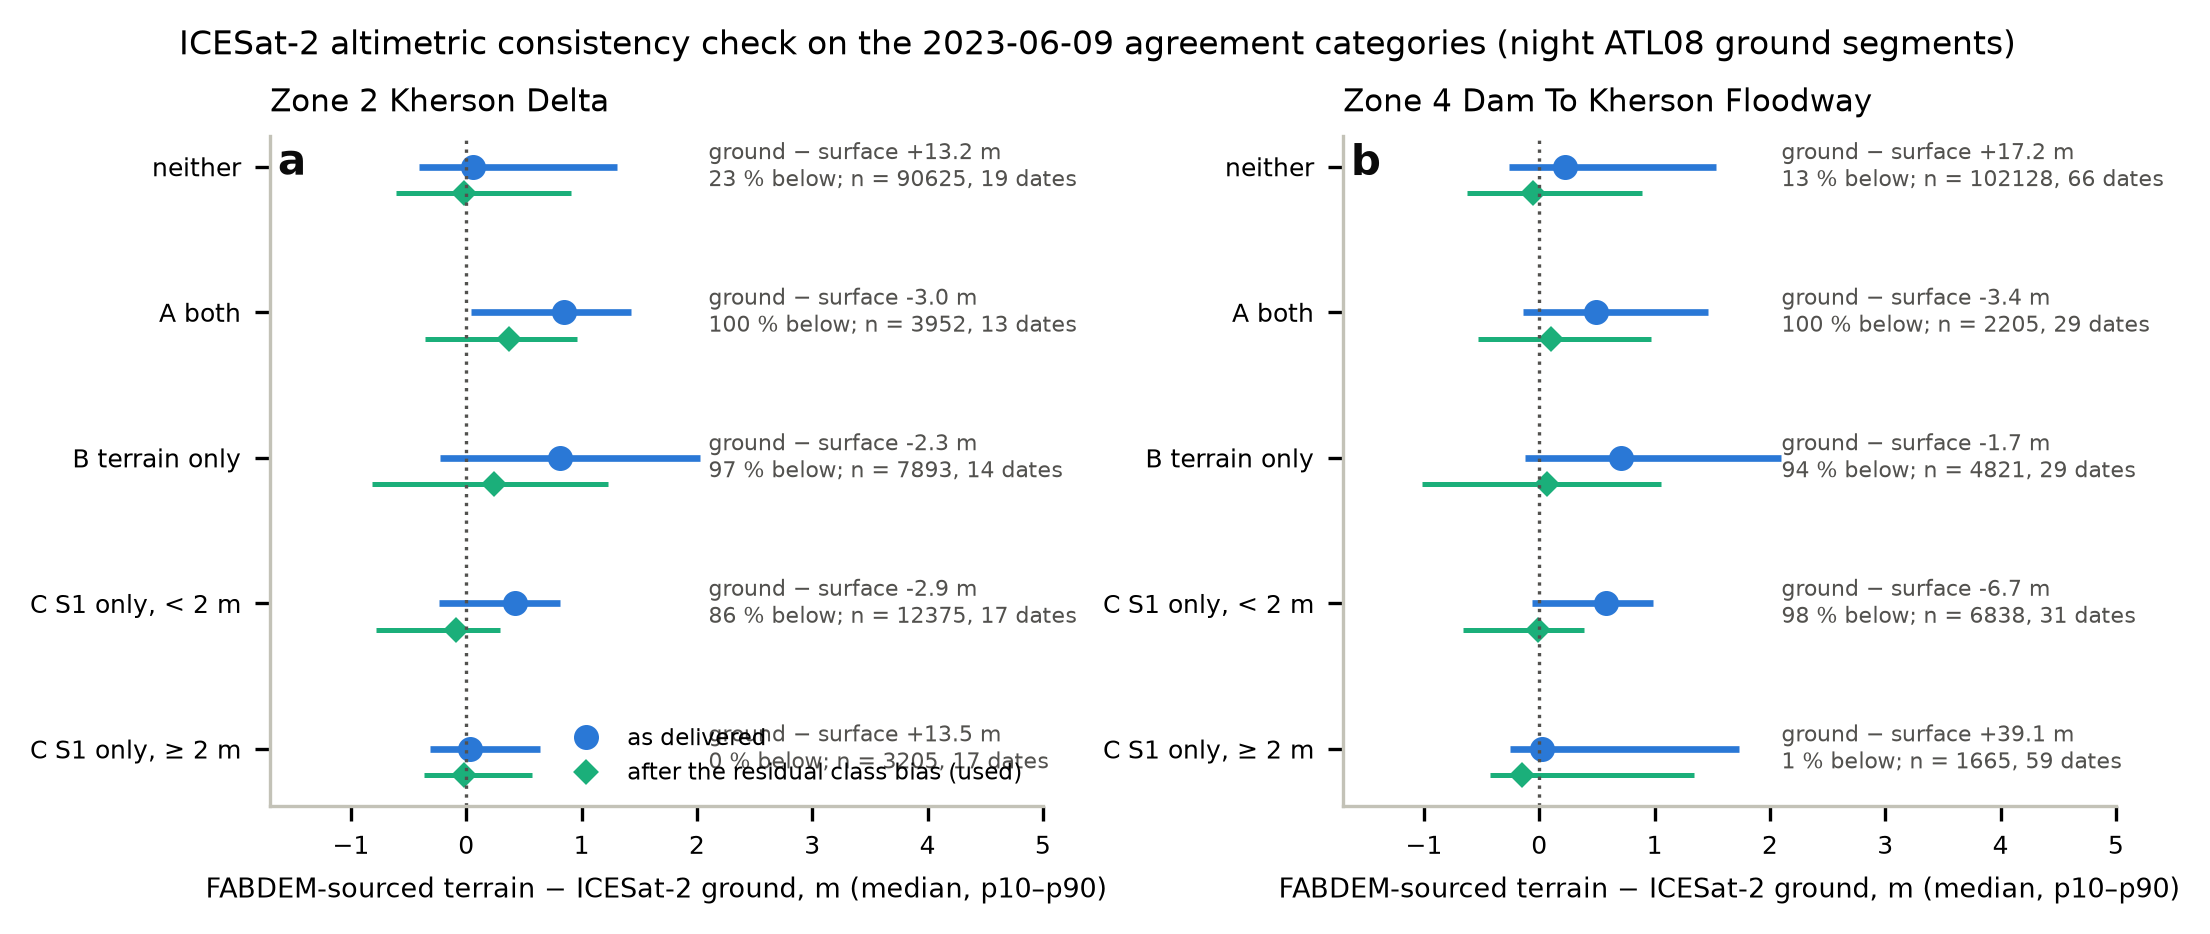

In [14]:
show('T15'); fig('Fig08')

## 6. Area accounting with semantics and the per-date series

In [15]:
show('T16')

**T16** [mixed] Area accounting with explicit semantics: observed (S1), mapped (U-Net), terrain-reconstructed and literature-reported figures are different quantities (new vs total water; snapshot vs cumulative vs persistence) and are never compared as validation.

,region,quantity,km2,area_semantics,quantity_semantics,temporal_semantics,unobserved_km2,verify,comparability_note
0,DNIPRO_CORRIDOR,"S1 new dark water, 06-09 scene",299.6,observed_S1,new_water (pre-breach water excluded),snapshot_2023-06-09,NaN,NaN,"quantities differ in area_semantics, quantity_..."
1,DNIPRO_CORRIDOR,"S1 new dark water, >= 2 of 3 peak dates (label...",167.8,observed_S1,new_water (pre-breach water excluded),"persistence_2of3_(06-09,06-13,06-14)",NaN,NaN,"quantities differ in area_semantics, quantity_..."
2,DNIPRO_CORRIDOR,"S1 total dark water, 06-09 (incl. pre-breach w...",682.5,observed_S1,total_water,snapshot_2023-06-09,NaN,NaN,"quantities differ in area_semantics, quantity_..."
3,DNIPRO_CORRIDOR,pre-breach water (S1 06-01/02 or p60 pre_water...,594.4,observed_S1,reference_water,reference_2023-06-01/02,NaN,NaN,"quantities differ in area_semantics, quantity_..."
4,DNIPRO_CORRIDOR,U2b predicted event flood (persistent concept),241.0,mapped_UNet,new_water (label concept),persistence (label concept ~13 June regime),NaN,NaN,"quantities differ in area_semantics, quantity_..."
5,INHULETS_VALLEY_rect,"S1 new dark water, 06-09 scene",36.1,observed_S1,new_water (pre-breach water excluded),snapshot_2023-06-09,NaN,NaN,"quantities differ in area_semantics, quantity_..."
6,INHULETS_VALLEY_rect,"S1 new dark water, >= 2 of 3 peak dates (label...",27.2,observed_S1,new_water (pre-breach water excluded),"persistence_2of3_(06-09,06-13,06-14)",NaN,NaN,"quantities differ in area_semantics, quantity_..."
7,INHULETS_VALLEY_rect,"S1 total dark water, 06-09 (incl. pre-breach w...",67.6,observed_S1,total_water,snapshot_2023-06-09,NaN,NaN,"quantities differ in area_semantics, quantity_..."
8,INHULETS_VALLEY_rect,pre-breach water (S1 06-01/02 or p60 pre_water...,91.0,observed_S1,reference_water,reference_2023-06-01/02,NaN,NaN,"quantities differ in area_semantics, quantity_..."
9,INHULETS_VALLEY_rect,U2b predicted event flood (persistent concept),30.4,mapped_UNet,new_water (label concept),persistence (label concept ~13 June regime),NaN,NaN,"quantities differ in area_semantics, quantity_..."


**T19** [cross_sensor] Per-acquisition-date new water (not water before the breach) inside the Sentinel-1 observable domain, with coverage; S2 only where >= 30 % of the region was cloud-free; estuary zone on its own grid.

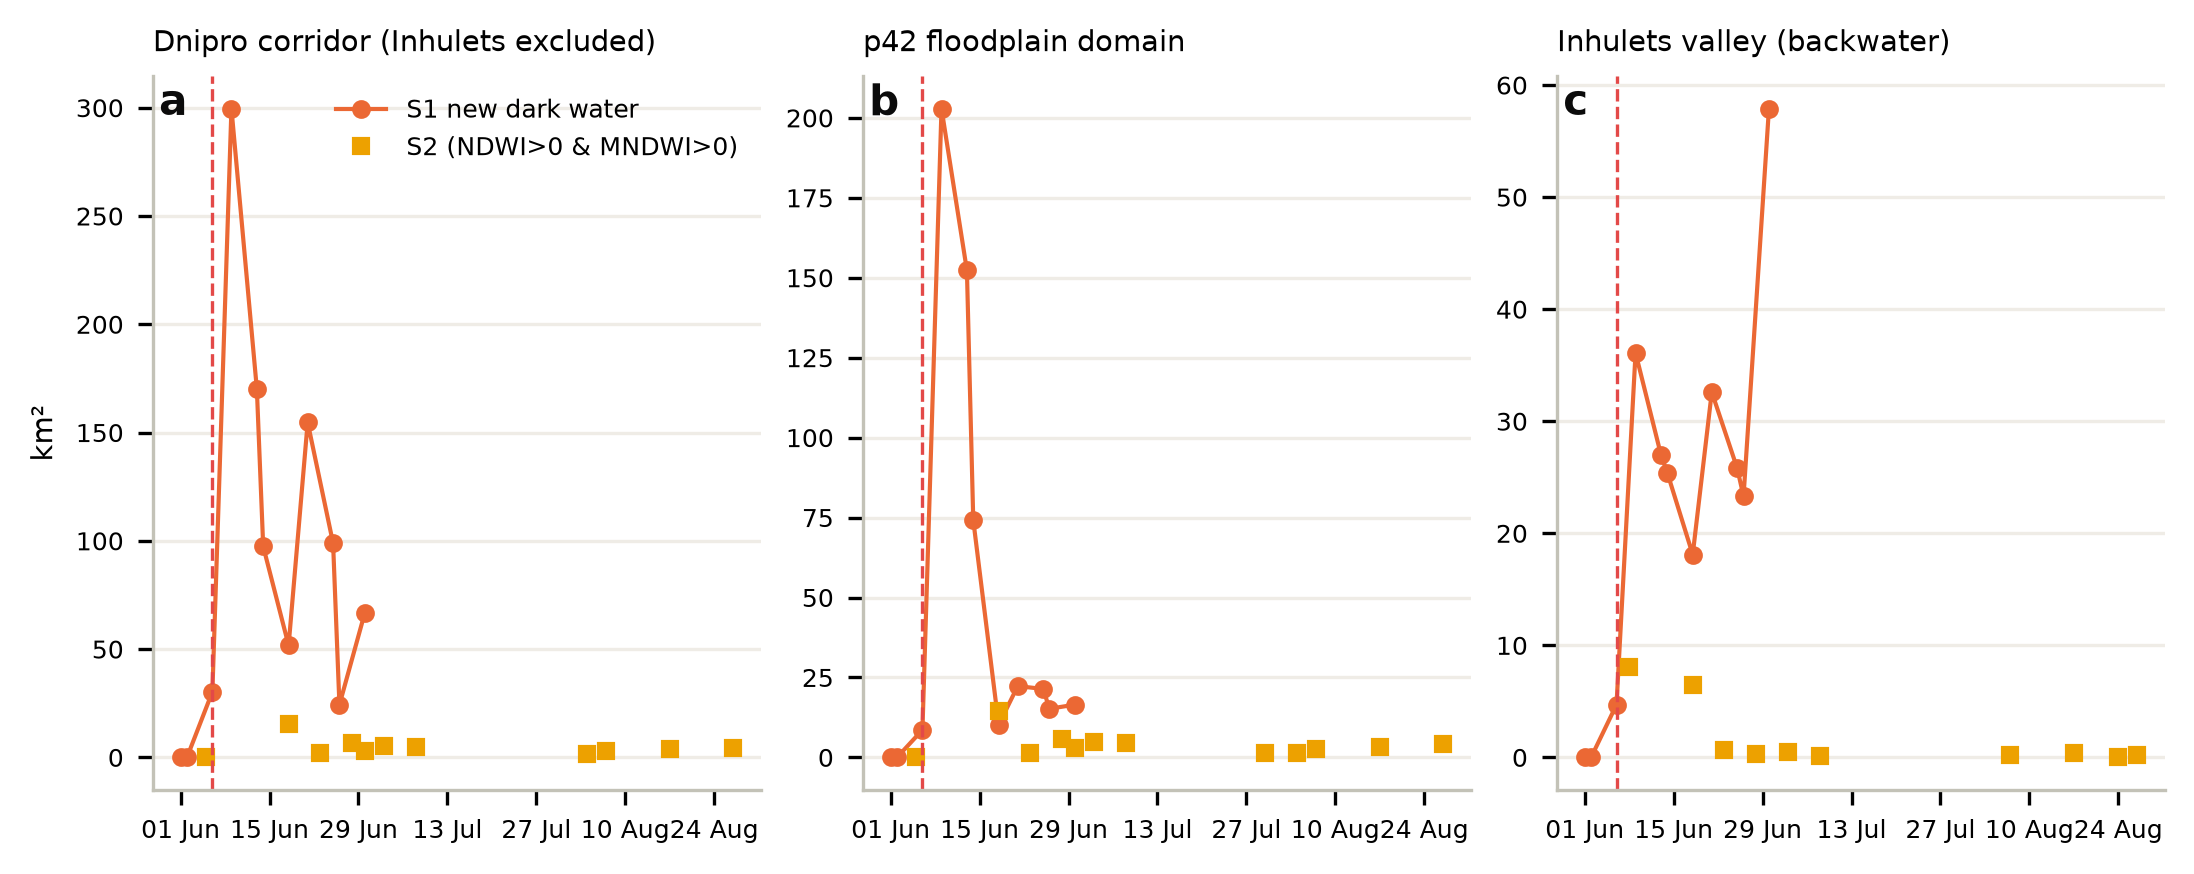

In [16]:
show('T19', 30); fig('FigS03')

## 7. Sensitivities
Rules, closure (superseded p59 chain) and the DEM accuracy that feeds the error model (Paper 2).

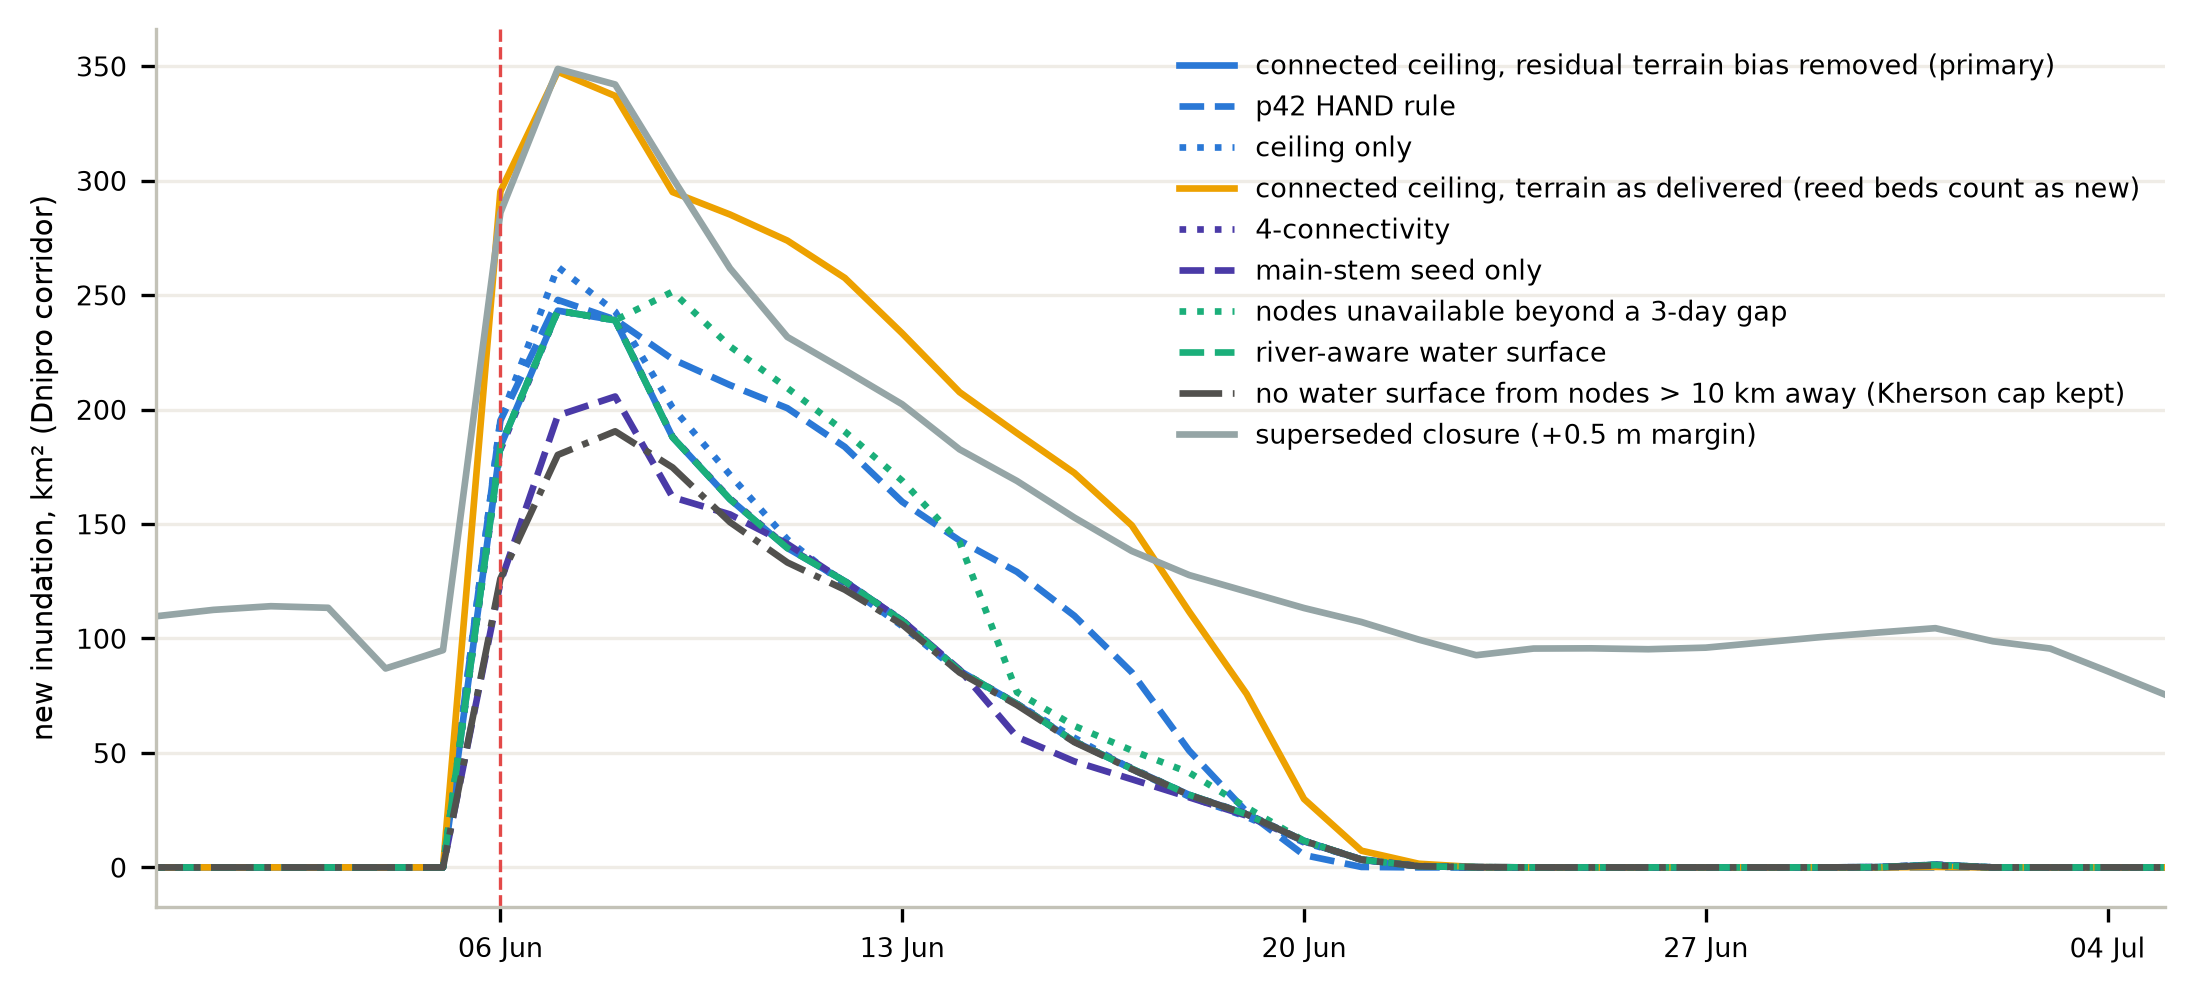

**T18** [independent_physical] Seamless terrain-bed model accuracy against night ICESat-2 ground segments (Paper 2 / p57): RMSE, MAE, bias, median, LE90, LE95, NMAD by zone and WorldCover class, all sources together (context; the uncertainty model uses the FABDEM-only rows of T18b).

,set,N,RMSE,MAE,bias,median,LE90,LE95,NMAD,product,zone,source
0,C seamless DEM (p55) -- ALL night points (land...,841752,1.044,0.495,0.266,0.085,1.033,1.773,0.390,C,NaN,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
1,"C seamless, ZONE_2_KHERSON_DELTA",153342,1.110,0.458,0.199,-0.002,0.982,1.655,0.299,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
2,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover t...",8066,3.024,2.085,1.952,1.481,4.741,6.169,1.603,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
3,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover g...",29227,1.329,0.653,0.372,0.107,1.422,2.220,0.491,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
4,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover c...",95454,0.408,0.198,-0.035,-0.059,0.404,0.537,0.195,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
5,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover b...",7850,1.901,0.818,0.252,0.151,1.764,2.581,0.696,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
6,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover bare",287,3.375,1.969,-0.819,-0.574,4.621,9.297,1.188,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
7,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover w...",12409,1.131,0.675,0.437,0.509,1.244,1.552,0.477,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
8,"C seamless, ZONE_4_DAM_TO_KHERSON_FLOODWAY",476545,1.125,0.551,0.408,0.225,1.153,2.017,0.385,C,ZONE_4_DAM_TO_KHERSON_FLOODWAY,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
9,"C seamless, ZONE_4_DAM_TO_KHERSON_FLOODWAY, Wo...",30020,2.929,2.190,2.079,1.693,4.639,5.791,1.715,C,ZONE_4_DAM_TO_KHERSON_FLOODWAY,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...


In [17]:
fig('FigS02'); show('T18')